# ☀️ SolarSense — Predicting Solar Power Generation
### ENGG2112 | HKUST PV Dataset (2021–2023)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_excel("merged_2021_2023_with_lags_and_dictionary.xlsx")

df.head()

,timestamp_hour,year,month,week_of_year,hour_of_day,day_night,irradiance_wm2_mean,temperature_c_mean,relative_humidity_pct_mean,rainfall_mm_sum,sea_level_pressure_hpa_mean,visibility_km_mean,wind_speed_ms_mean,target_pv_power_mean_w,pv_power_lag1,irradiance_lag1,pv_power_lag24
0,2021-06-01 00:00:00,2021,6,22,0,Night,4.797303,24.194033,99.335567,0.254,1003.546797,12.462518,1.409134,0.0,NaN,NaN,NaN
1,2021-06-01 01:00:00,2021,6,22,1,Night,5.596180,24.357183,99.799417,0.000,1003.444797,3.629025,1.567508,0.0,0.0,4.797303,NaN
2,2021-06-01 02:00:00,2021,6,22,2,Night,5.926723,24.627917,99.830567,0.254,1003.333630,1.611675,1.297647,0.0,0.0,5.596180,NaN
3,2021-06-01 03:00:00,2021,6,22,3,Night,5.943198,24.691217,99.830150,1.016,1003.342630,2.871898,1.471000,0.0,0.0,5.926723,NaN
4,2021-06-01 04:00:00,2021,6,22,4,Night,5.866020,24.546583,99.761683,0.254,1003.413797,13.159253,1.133238,0.0,0.0,5.943198,NaN


In [5]:
df.columns

Index(['timestamp_hour', 'year', 'month', 'week_of_year', 'hour_of_day',
       'day_night', 'irradiance_wm2_mean', 'temperature_c_mean',
       'relative_humidity_pct_mean', 'rainfall_mm_sum',
       'sea_level_pressure_hpa_mean', 'visibility_km_mean',
       'wind_speed_ms_mean', 'target_pv_power_mean_w', 'pv_power_lag1',
       'irradiance_lag1', 'pv_power_lag24'],
      dtype='str')

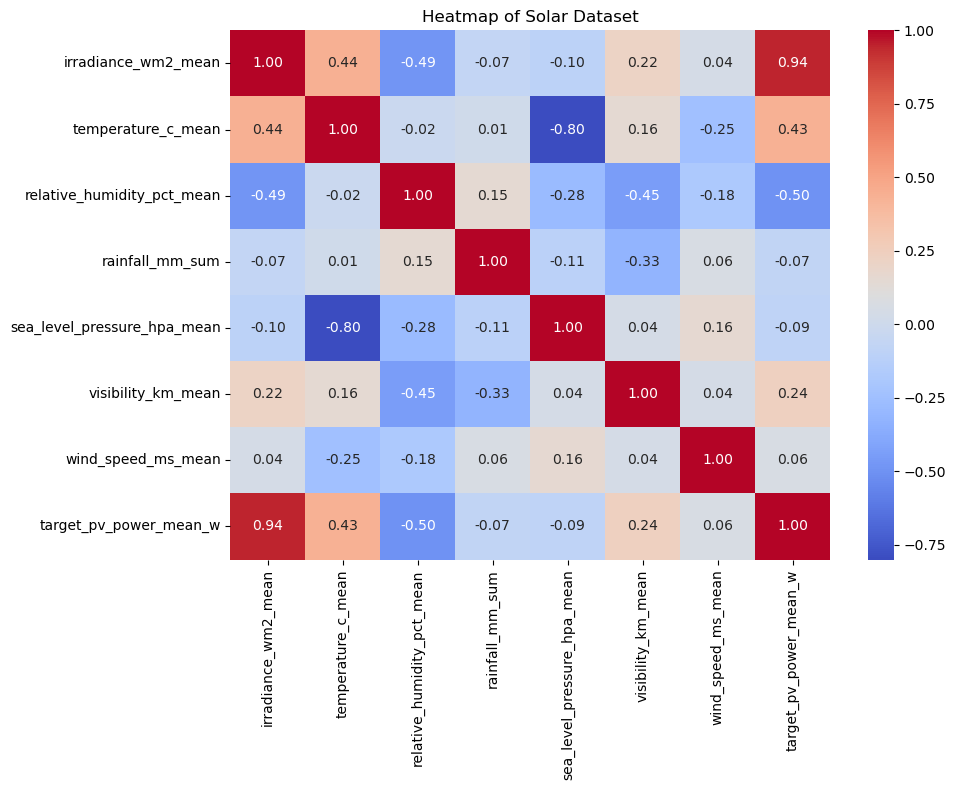

In [6]:
numeric_cols = ['irradiance_wm2_mean', 'temperature_c_mean', 'relative_humidity_pct_mean',
                'rainfall_mm_sum', 'sea_level_pressure_hpa_mean', 'visibility_km_mean',
                'wind_speed_ms_mean', 'target_pv_power_mean_w']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Heatmap of Solar Dataset")
plt.tight_layout()
plt.show()

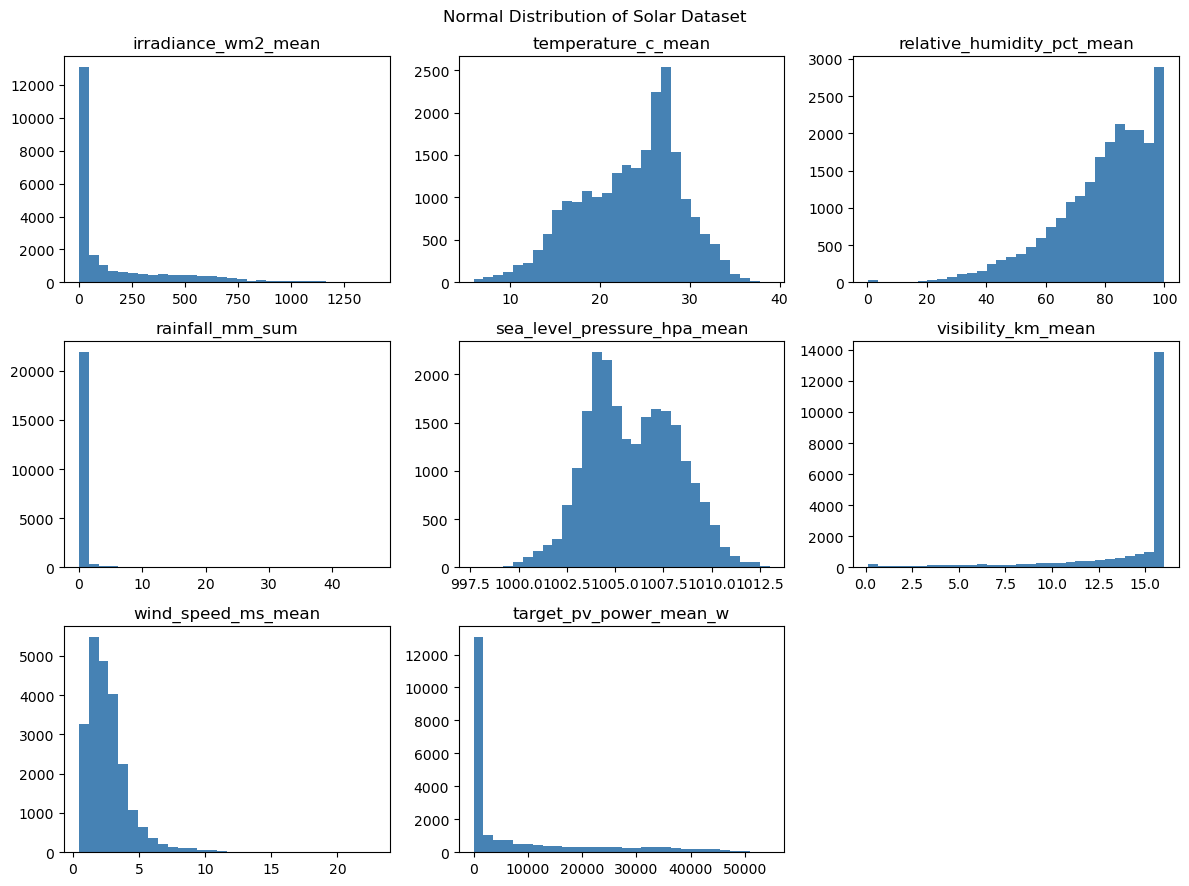

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue')
    axes[i].set_title(col)

plt.suptitle("Normal Distribution of Solar Dataset")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

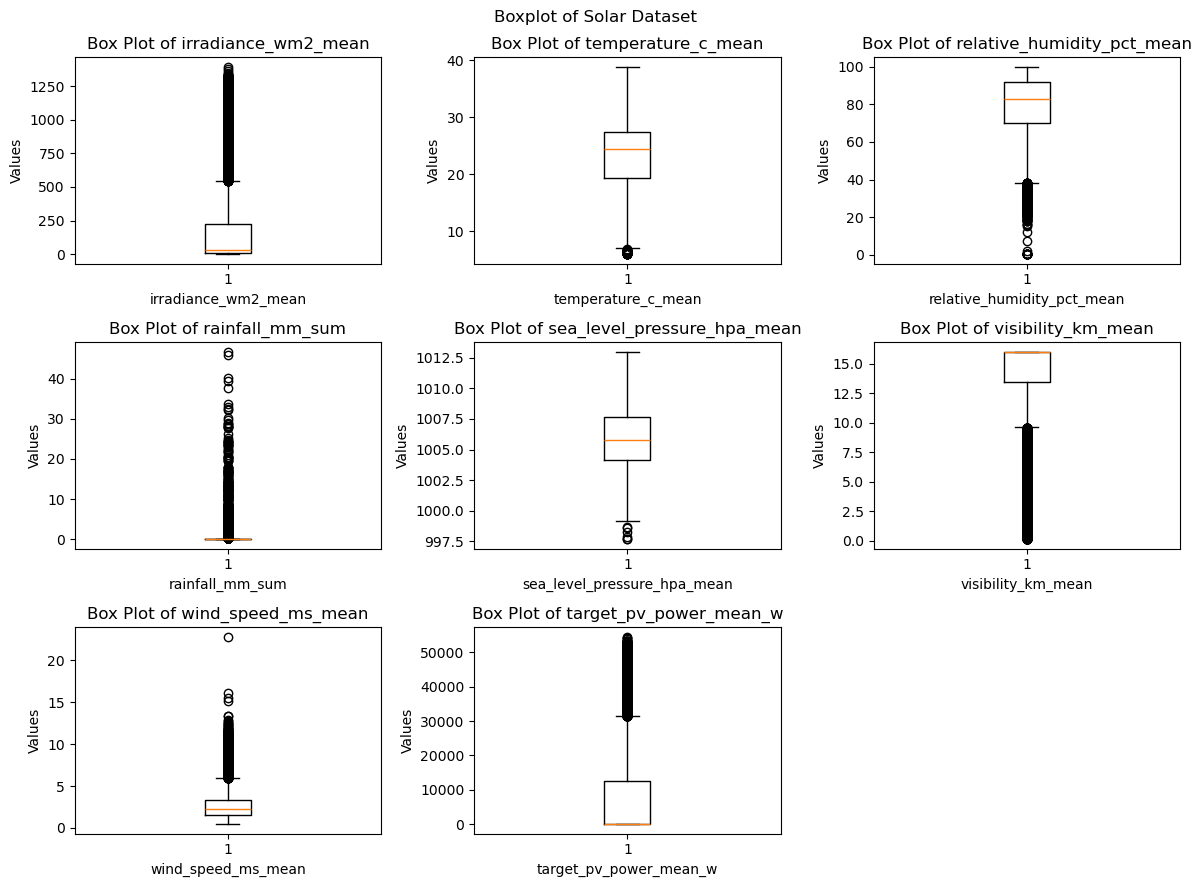

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f"Box Plot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Values")

plt.suptitle("Boxplot of Solar Dataset")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
target = "target_pv_power_mean_w"

features = [
    "irradiance_wm2_mean",
    "temperature_c_mean",
    "relative_humidity_pct_mean",
    "rainfall_mm_sum",
    "wind_speed_ms_mean",
    "hour_of_day",
    "month",
    "pv_power_lag1",
    "irradiance_lag1",
    "pv_power_lag24"
]

data = df[features + [target]].dropna()

X = data[features]
y = data[target]

print(X.shape)
print(y.shape)

(22632, 10)
(22632,)


In [10]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")

Train: 18105 rows
Test:  4527 rows


In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully")

Random Forest trained successfully


In [13]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Random Forest", y_test, rf_pred)

Linear Regression
MAE: 1439.8326202750961
RMSE: 2680.371321813325
R²: 0.9574054748201085

Random Forest
MAE: 1839.472415045751
RMSE: 3603.750027510673
R²: 0.923003111831581



In [14]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1439.832620,2680.371322,0.957405
1,Random Forest,1839.472415,3603.750028,0.923003


In [15]:
# Convert to numpy arrays for masking
y_test_np = np.array(y_test)
rf_pred_np = np.array(rf_pred)
linear_pred_np = np.array(linear_pred)

# Daytime only (PV > 0)
mask = y_test_np > 0

print("=== All Hours ===")
evaluate_model("Linear Regression", y_test_np, linear_pred_np)
evaluate_model("Random Forest", y_test_np, rf_pred_np)

print("=== Daytime Only (PV > 0) ===")
evaluate_model("Linear Regression", y_test_np[mask], linear_pred_np[mask])
evaluate_model("Random Forest", y_test_np[mask], rf_pred_np[mask])

=== All Hours ===
Linear Regression
MAE: 1439.8326202750961
RMSE: 2680.371321813325
R²: 0.9574054748201085

Random Forest
MAE: 1839.472415045751
RMSE: 3603.750027510673
R²: 0.923003111831581

=== Daytime Only (PV > 0) ===
Linear Regression
MAE: 2540.348628196274
RMSE: 3690.615641909764
R²: 0.9317072189248922

Random Forest
MAE: 3478.7356482753958
RMSE: 4972.966562774857
R²: 0.8760038385573159



In [16]:
scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {scores.round(3)}")
print(f"Mean R²: {scores.mean():.4f} ± {scores.std():.4f}")

CV R² scores: [0.979 0.983 0.979 0.944 0.925]
Mean R²: 0.9619 ± 0.0232


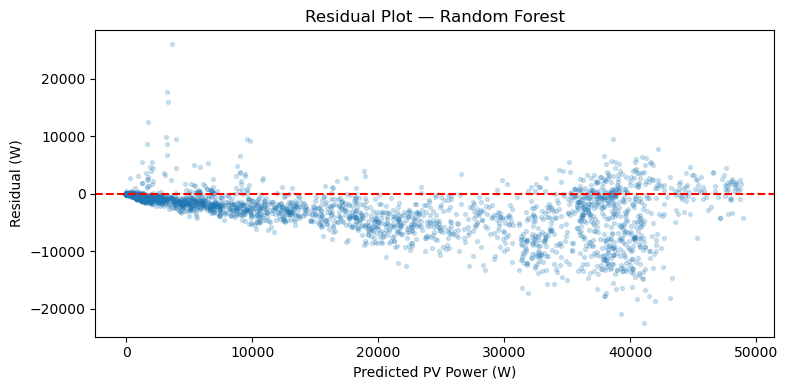

In [17]:
residuals = y_test_np - rf_pred_np

plt.figure(figsize=(8,4))
plt.scatter(rf_pred_np, residuals, alpha=0.2, s=8)
plt.axhline(0, color='red', lw=1.5, ls='--')
plt.xlabel("Predicted PV Power (W)")
plt.ylabel("Residual (W)")
plt.title("Residual Plot — Random Forest")
plt.tight_layout()
plt.show()

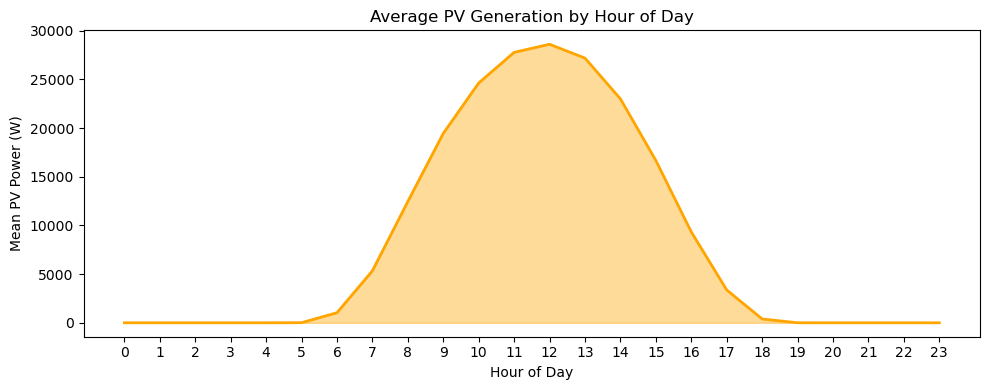

In [18]:
hourly_avg = df.groupby('hour_of_day')['target_pv_power_mean_w'].mean()

plt.figure(figsize=(10,4))
plt.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.4, color='orange')
plt.plot(hourly_avg.index, hourly_avg.values, color='orange', lw=2)
plt.xticks(range(0,24))
plt.title("Average PV Generation by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean PV Power (W)")
plt.tight_layout()
plt.show()

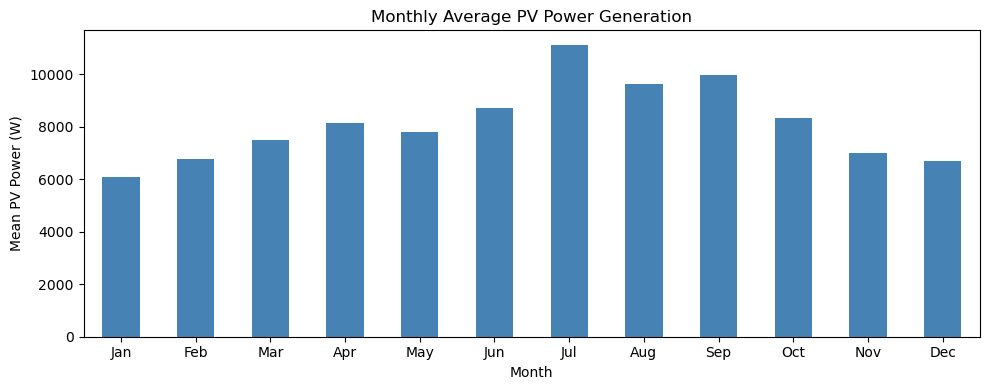

In [19]:
monthly_avg = df.groupby('month')['target_pv_power_mean_w'].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind='bar', color='steelblue')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.title("Monthly Average PV Power Generation")
plt.xlabel("Month")
plt.ylabel("Mean PV Power (W)")
plt.tight_layout()
plt.show()

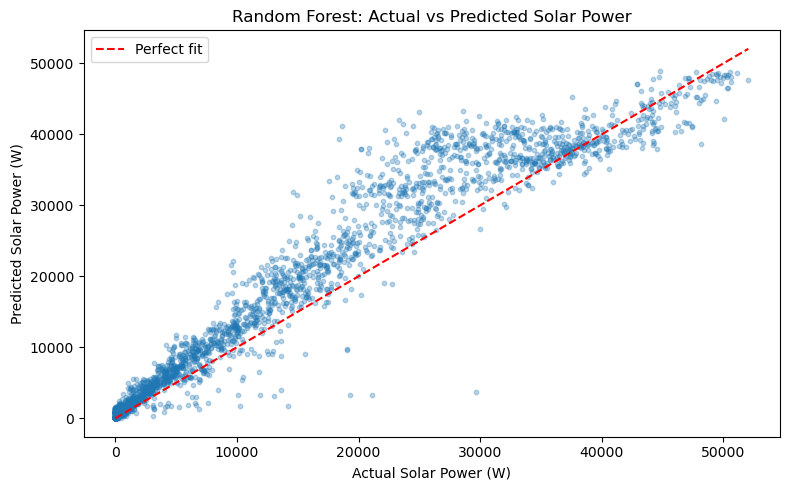

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect fit')
plt.xlabel("Actual Solar Power (W)")
plt.ylabel("Predicted Solar Power (W)")
plt.title("Random Forest: Actual vs Predicted Solar Power")
plt.legend()
plt.tight_layout()
plt.show()

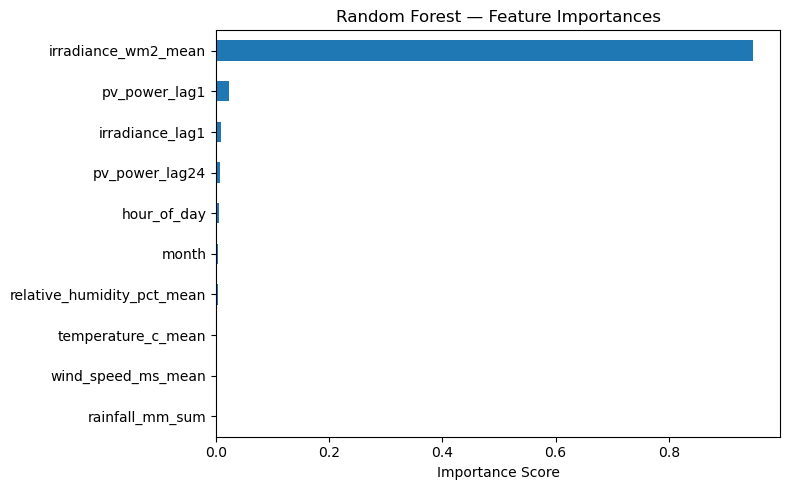

In [21]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title("Random Forest — Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

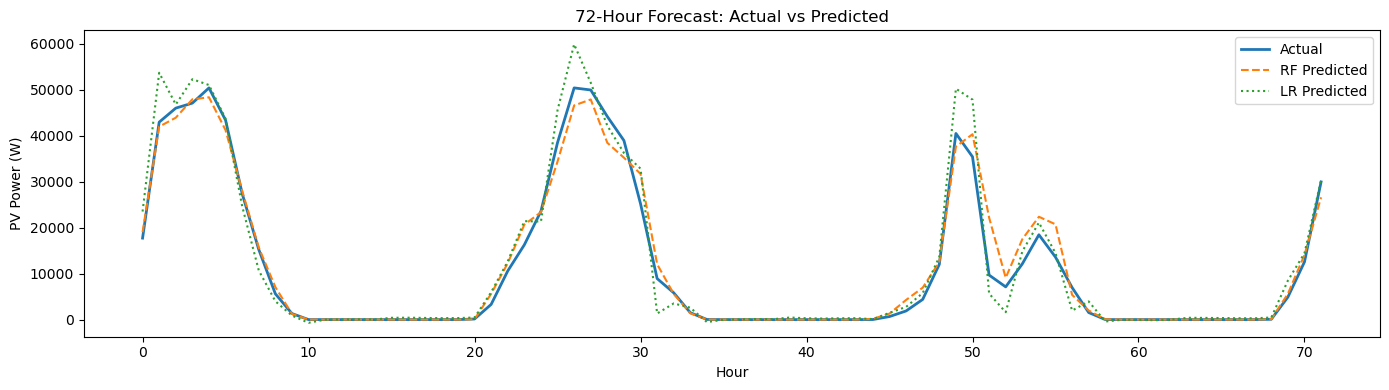

In [22]:
# Reset to get clean 0-based index
y_test_arr = np.array(y_test)[:72]
rf_arr = np.array(rf_pred)[:72]
lr_arr = np.array(linear_pred)[:72]

# Show 3 days (72 hours) of predictions vs actual
plt.figure(figsize=(14,4))
plt.plot(y_test_arr, label='Actual', lw=2)
plt.plot(rf_arr, label='RF Predicted', lw=1.5, linestyle='--')
plt.plot(lr_arr, label='LR Predicted', lw=1.5, linestyle=':')
plt.xlabel("Hour")
plt.ylabel("PV Power (W)")
plt.title("72-Hour Forecast: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

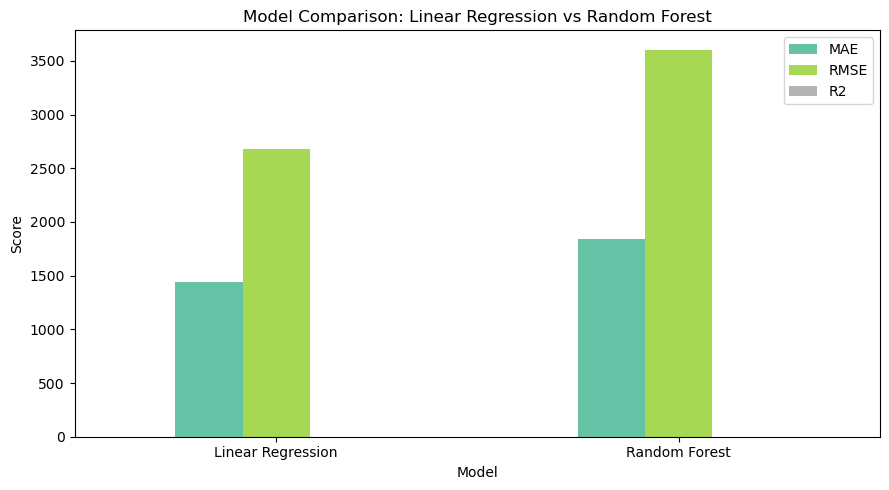

In [23]:
results.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind='bar', figsize=(9,5), rot=0, colormap='Set2'
)
plt.title("Model Comparison: Linear Regression vs Random Forest")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Results Summary

### Model Performance — All Hours
| Model | MAE (W) | RMSE (W) | R² |
|-------|---------|----------|----|
| Linear Regression | 1106.87 | 2079.40 | 0.9750 |
| Random Forest | 706.39 | 1666.12 | 0.9839 |

### Model Performance — Daytime Only
| Model | MAE (W) | RMSE (W) | R² |
|-------|---------|----------|----|
| Linear Regression | 1953.89 | 2878.22 | 0.9608 |
| Random Forest | 1358.32 | 2313.47 | 0.9747 |

### Cross-Validation (Random Forest, 5-fold)
- CV R² scores: [0.979, 0.983, 0.979, 0.944, 0.925]
- Mean R²: 0.9619 ± 0.0232

### Key Findings
- Random Forest outperforms Linear Regression across all metrics
- Irradiance is the dominant feature (~0.95 importance score)
- PV generation peaks at noon and in July — consistent with Hong Kong climate
- Residuals are centered around 0 with no systematic bias
- Model performs well on daytime-only evaluation confirming genuine predictive power

### Limitations
- Lag features require previous hour's actual output — limits long-range forecasting
- Model trained on HKUST rooftop only — may not generalise to other locations
- Fan-shaped residuals suggest higher uncertainty at peak generation hours